This notebook is an initial demo showing how the ZCU can send a signal from its DAC to its ADC, and what it looks like to graph the frequency sent vs the magnitude.

We will be using tProc channel 7: DAC 229 CH3 <-> Readout channel 0 : ADC 224 CH0 (*TODO* Check that this maps to our balun adapter)

In [1]:
import pynq
from qick import *
from qick.asm_v2 import AveragerProgramV2
from tqdm.notebook import tqdm
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [2]:
# Load bitstream with custom overlay

soc = QickSoc(bitfile="../../qick/firmware/projects/2024-09-03_216_tprovc2r21_demo/qick_216.bit")
# Since we're running locally on the QICK, we don't need a separate QickConfig object.
# See other demos for more info on that
soccfg = soc
print(soccfg)

QICK running on ZCU216, software version 0.2.396

Firmware configuration (built Tue Sep  3 12:55:04 2024):

	Global clocks (MHz): tProc dispatcher timing 614.400, RF reference 245.760
	Groups of related clocks: [tProc timing clock, DAC tile 2], [DAC tile 3], [ADC tile 2]

	5 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9830.400 Msps, fabric=614.400 MHz
		envelope memory: 16384 complex samples (1.667 us)
		32-bit DDS, range=9830.400 MHz
		DAC tile 2, blk 0 is 0_230 on JHC3, or XM655 DAC port 8
	1:	axis_sg_int4_v2 - fs=6881.280 Msps, fabric=430.080 MHz
		envelope memory: 4096 complex samples (9.524 us)
		32-bit DDS, range=1720.320 MHz
		DAC tile 3, blk 0 is 0_231 on JHC3, or XM655 DAC port 12
	2:	axis_sg_int4_v2 - fs=6881.280 Msps, fabric=430.080 MHz
		envelope memory: 4096 complex samples (9.524 us)
		32-bit DDS, range=1720.320 MHz
		DAC tile 3, blk 1 is 1_231 on JHC4, or XM655 DAC port 13
	3:	axis_sg_mux8_v1 - fs=9830.400 Msps, fabric=614.400 MHz
		32-bit DDS, range=9830.400 

We create a LoopbackProgram class which takes advantage of AveragerProgram. This comes directly from the "02_Sweeping_variables" demo. It allows us to sweep the frequency using Python instead of QICK. Do note that this is slower than using QICK, but good enough for our current purposes.

In [5]:
class LoopbackProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        self.declare_gen(ch=cfg["res_ch"], nqz=cfg["nqz"])
        self.declare_readout(ch=cfg["ro_ch"], length=cfg["readout_length"])  # freq/gen_ch removed

        self.add_pulse(ch=cfg["res_ch"], name="readout_pulse",
                       style="const",
                       freq=cfg["pulse_freq"],
                       phase=0,
                       gain=cfg["pulse_gain"],
                       length=cfg["length"])

        self.delay_auto(0.5)  # delay in µs, gives time for pulse configuration to settle

    def _body(self, cfg):
        self.pulse(ch=cfg["res_ch"], name="readout_pulse")
        self.trigger(ros=[cfg["ro_ch"]], t=0.5)  # offset in µs
        self.delay_auto(cfg["relax_delay"])

Build the config object we will pass to LoopbackProgram

In [12]:
config={"res_ch":1, # --Fixed DAC channel
        "ro_ch":2, # --Fixed ADC channel
        "nqz":2,
        "relax_delay":1, # --Fixed
        "res_phase":0, # --Fixed
        "pulse_style": "const", # --Fixed
        "length":0.5, # microseconds
        "readout_length":200, # [Clock ticks]
        "pulse_gain": 30000, # 32767, # [DAC units]
        "pulse_freq": 100, # [MHz] we will overwrite this in our loop
        "adc_trig_offset": 100, # [Clock ticks]
        "reps":100, 
       }

Get the magnitudes

In [13]:
# Define frequency range
freqs = np.linspace(5000, 9000, 200)  # MHz
mags = []
Is, Qs = [], []

for f in tqdm(freqs, desc="Frequency sweep"):
    config['pulse_freq'] = f
    prog = LoopbackProgram(soccfg, reps=config["reps"], final_delay=config["relax_delay"], cfg=config)
    avg_d = prog.acquire(soc, progress=False)#, rounds=20)
    # avg_d is a list of [I, Q] arrays per readout channel
    I = avg_d[0][0][0]  # ro_ch 0, rep 0, I
    Q = avg_d[0][0][1]  # ro_ch 0, rep 0, Q
    Is.append(I)
    Qs.append(Q)
    mags.append(np.abs(I + 1j*Q))

Frequency sweep:   0%|          | 0/200 [00:00<?, ?it/s]

RuntimeError: generator 1 has a digital mixer, but no mixer_freq was defined

Finally we plot frequency vs. magnitude

ValueError: x and y must have same first dimension, but have shapes (200,) and (0,)

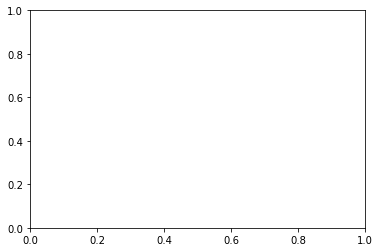

In [14]:
plt.plot(freqs, mags, '.')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Magnitude (ADU)')
plt.title('Transmission vs Frequency (Loopback)')
# plt.semilogy()
plt.show()

In [113]:
from datetime import datetime

# Create a timestamp for unique filenames
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Save numerical data
np.savez(f"loopback_sweep_{timestamp}.npz",
         freqs=np.array(freqs),
         mags=np.array(mags),
         I=np.array(Is),      # make sure you're storing I/Q in your loop
         Q=np.array(Qs))

# Save the plot
plt.savefig(f"loopback_sweep_{timestamp}.png", dpi=150, bbox_inches='tight')

print(f"Saved loopback_sweep_{timestamp}.npz and .png")

Saved loopback_sweep_20260505_155151.npz and .png


<Figure size 432x288 with 0 Axes>